In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
txt = 'The way you do anything is the way you do everything.'

characters = [c for c in txt]

print('The full text:\n', txt, '\n')
print('As a list of characters:\n', characters, '\n')

char_vocab = list(sorted(set(characters)))
print('The vocabulary is:\n', char_vocab, '\n')

print(f'There are {len(characters)} characters, {len(char_vocab)} of which are unique.')

The full text:
 The way you do anything is the way you do everything. 

As a list of characters:
 ['T', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'a', 'n', 'y', 't', 'h', 'i', 'n', 'g', ' ', 'i', 's', ' ', 't', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'e', 'v', 'e', 'r', 'y', 't', 'h', 'i', 'n', 'g', '.'] 

The vocabulary is:
 [' ', '.', 'T', 'a', 'd', 'e', 'g', 'h', 'i', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'y'] 

There are 53 characters, 18 of which are unique.


In [3]:
print('Token :', end='')
for v in char_vocab:
    print(f' "{v}" | ', end='')
print('\n', '-'*131)

print('Index :', end='')
[print(f' {i:2} |', end='') for i in range(len(char_vocab))];

Token : " " |  "." |  "T" |  "a" |  "d" |  "e" |  "g" |  "h" |  "i" |  "n" |  "o" |  "r" |  "s" |  "t" |  "u" |  "v" |  "w" |  "y" | 
 -----------------------------------------------------------------------------------------------------------------------------------
Index :  0 |  1 |  2 |  3 |  4 |  5 |  6 |  7 |  8 |  9 | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 |

In [4]:
tokens = [0]*len(txt)
for i, c in enumerate(txt):
    tokens[i] = char_vocab.index(c)
print(tokens)

[2, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 3, 9, 17, 13, 7, 8, 9, 6, 0, 8, 12, 0, 13, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 5, 15, 5, 11, 17, 13, 7, 8, 9, 6, 1]


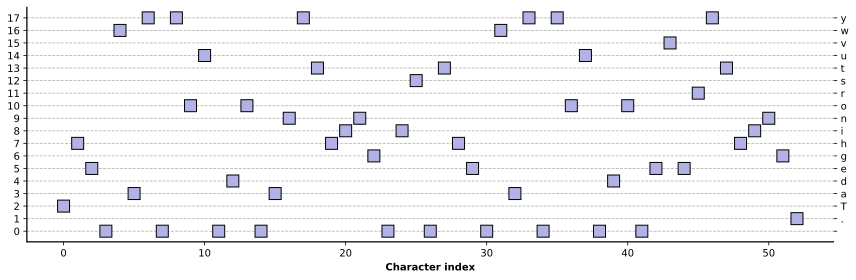

In [5]:
_, ax = plt.subplots(1, figsize=(12,4))

ax.plot(tokens, 'ks', markersize=12, markerfacecolor=[.7, .7, .9])
ax.set(xlabel='Character index', yticks=range(len(char_vocab)))
ax.grid(linestyle='--', axis='y')

ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(char_vocab)), yticklabels=char_vocab)

plt.tight_layout()
plt.savefig('ch2_proj1_part1-tokenscatter.png')
plt.show()

In [6]:
words = txt.split()

print('The list of word is:\n', words, '\n')
word_vocab = list(sorted(set(words)))
print(f'There are {len(words)} words, {len(word_vocab)}  of which are unique.\n')
print('The vocab is:\n', word_vocab)

The list of word is:
 ['The', 'way', 'you', 'do', 'anything', 'is', 'the', 'way', 'you', 'do', 'everything.'] 

There are 11 words, 8  of which are unique.

The vocab is:
 ['The', 'anything', 'do', 'everything.', 'is', 'the', 'way', 'you']


In [7]:
tokens = [0]*len(words)

for i, c in enumerate(words):
    tokens[i] = word_vocab.index(c)

print(tokens)

[0, 6, 7, 2, 1, 4, 5, 6, 7, 2, 3]


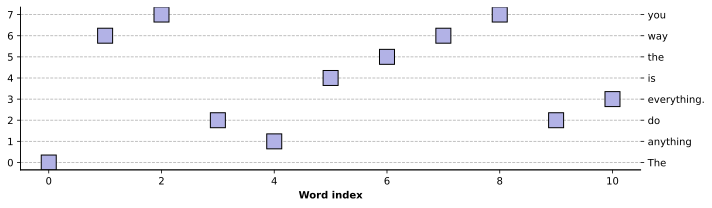

In [8]:
_, ax = plt.subplots(1, figsize=(10,3))

ax.plot(tokens, 'ks', markersize=15, markerfacecolor=[.7, .7, .9])
ax.set(xlabel='Word index', yticks=range(len(word_vocab)))
ax.grid(linestyle='--', axis='y')

ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(word_vocab)), yticklabels=word_vocab)

plt.tight_layout()
plt.savefig('ch2_proj1_part2.png')
plt.show()

In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
tokenizer.vocab_size

50257

In [11]:
gpt2_tokens = tokenizer.encode(txt)

for token in gpt2_tokens:
    print(f'Token {token: 4} if "{tokenizer.decode([token])}"')

Token  464 if "The"
Token  835 if " way"
Token  345 if " you"
Token  466 if " do"
Token  1997 if " anything"
Token  318 if " is"
Token  262 if " the"
Token  835 if " way"
Token  345 if " you"
Token  466 if " do"
Token  2279 if " everything"
Token   13 if "."


In [12]:
word1 = ' Mike'
word2 = 'Mike'

for w in [word1, word2]:
    print(f'Token for "{w}" is {tokenizer.encode(w)}')

Token for " Mike" is [4995]
Token for "Mike" is [16073]


In [13]:
print(f'There are {len(gpt2_tokens)} tokens, {len(set(gpt2_tokens))} of which are unique.')

There are 12 tokens, 9 of which are unique.


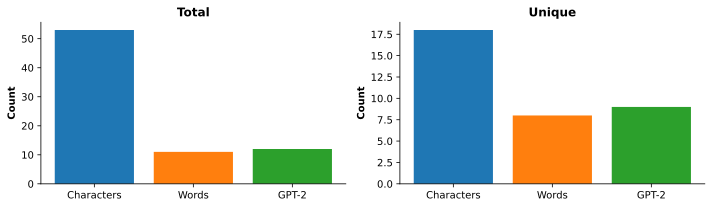

In [14]:
_, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].bar(0, len(characters))
axs[0].bar(1, len(words))
axs[0].bar(2, len(gpt2_tokens))
axs[0].set(xticks=[0, 1, 2], xticklabels=['Characters', 'Words', 'GPT-2'], ylabel='Count', title='Total')

axs[1].bar(0, len(char_vocab))
axs[1].bar(1, len(word_vocab))
axs[1].bar(2, len(set(gpt2_tokens)))
axs[1].set(xticks=[0, 1, 2], xticklabels=['Characters', 'Words', 'GPT-2'], ylabel='Count', title='Unique')

plt.tight_layout()
plt.savefig('ch2_proj1_part3.png')
plt.show()
